## Imports

In [62]:
%load_ext autoreload
%autoreload 2
import jax
import matplotlib.pyplot as plt
import pandas as pd

from eci.environment import Environment
from eci.metrics import batch_compute_metrics
from eci.plots import plot_preference, plot_voting_metrics
from eci.voting_system.plurality import _vote_plurality
from eci.voting_system.quadratic import _vote_quadratic
from eci.voting_system.random_voting import _vote_random

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Parameter Configuration 
The simulation constants are defined here.

In [55]:
NUM_VOTERS = 50  # Number of voters
NUM_CANDIDATES = 16  # Number of candidates
NUM_PREFERENCES = 3  # Number of preferences per voter
NUM_SIMULATIONS = 1000  # Number of simulation steps (trajectories)

## Environment Initialization 
The environment is created using the parameters defined above.

In [56]:
# Initialize environment
env = Environment(
    num_voters=NUM_VOTERS,  # Number of voters
    num_candidates=NUM_CANDIDATES,  # Number of candidates
    num_preferences=NUM_PREFERENCES,  # Number of preferences
)
env.num_simulations = NUM_SIMULATIONS  # Number of simulations
env._run_multi_agent_inference()

/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_24618/3629702636.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_preference(env).show()


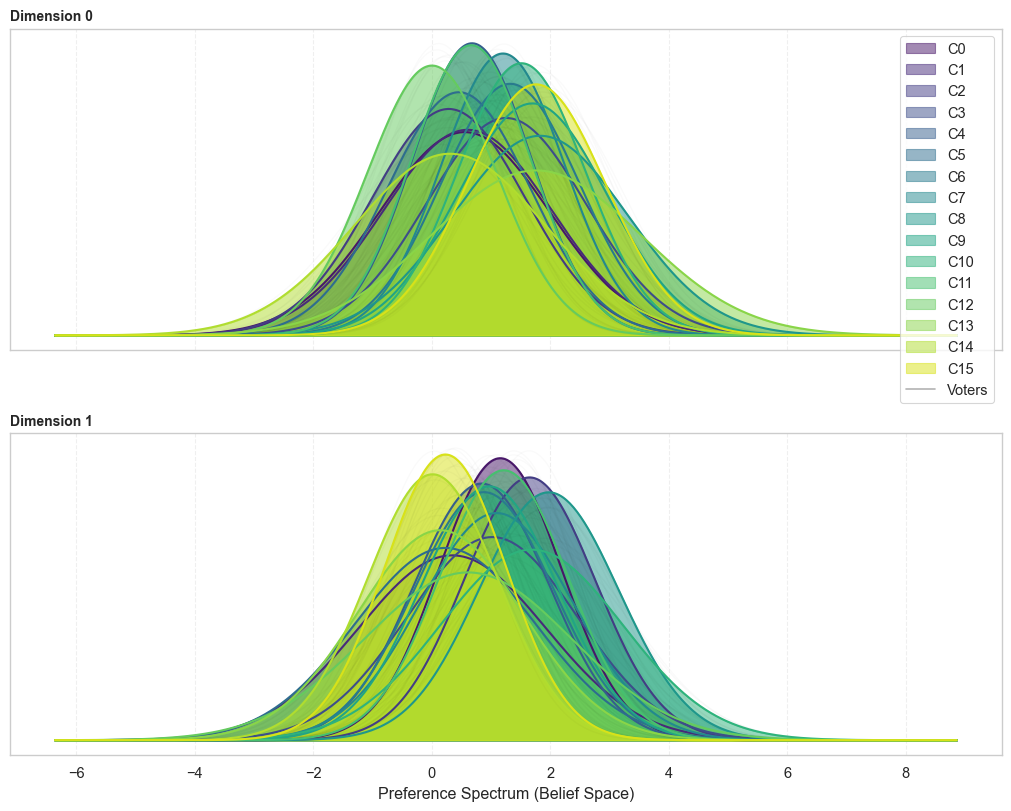

In [57]:
plot_preference(env).show()

## Running the Simulation

### Random Voting

In [58]:
# intiatialize random key
key = jax.random.PRNGKey(42)

# Run simulations
sim_rdm = env.run_n_simulation(_vote_random, key, NUM_SIMULATIONS)

# Update environment and agents
# env._update_agents()

# Compute metrics
metrics_rdm = batch_compute_metrics(sim_rdm)

# compute vote shares
# distribution_rdm = compute_vote_shares(sim_rdm, num_candidates=7)

### Plurality Voting

In [59]:
# intiatialize random key
key = jax.random.PRNGKey(42)

# Run simulations
sim_plurality = env.run_n_simulation(_vote_plurality, key, NUM_SIMULATIONS)

# Update environment and agents
# env._update_agents()

# Compute metrics
metrics_plurality = batch_compute_metrics(sim_plurality)

# compute vote shares
# distribution_plurality = compute_vote_shares(sim_plurality, num_candidates=7)

### Quadratic Voting

In [60]:
# Run perception
env._run_multi_agent_inference()

# intiatialize random key
key = jax.random.PRNGKey(42)

# Run simulations
sim_qv = env.run_n_simulation(_vote_quadratic, key, NUM_SIMULATIONS)

# Update environment and agents
# env._update_agents()

# Compute metrics
# TODO: how to compute to compare?
metrics_qv = batch_compute_metrics(sim_qv)

# Metrics

## Winner Satisfaction (Total Gap)

This measures the aggregate alignment of the electorate with the winning candidate.$$S_{winner} = \sum_{v \in \text{Voters}} P_{v, \text{winner}}$$Code: winner_satisfaction = candidate_preferences[:, winner]Meaning: It sums the preference score (or gap) that every voter has for the specific candidate who won.High Value: The winner is far from the voters' ideals (high aggregate regret).Low Value: The winner is close to the voters' ideals (high consensus).

## Vote Efficiency

This measures the "quality" of the votes cast in Round 1. It checks if the votes voters cast actually aligned with their internal preferences.$$E_{total} = \sum_{v \in \text{Voters}} \left( \frac{\sum_{c} (Vote_{v,c} \cdot P_{v,c})}{\sum_{c} Vote_{v,c}} \right)$$Code: weighted_gaps = votes_matrix * candidate_preferencesLogic:It weights the voter's preference for a candidate by how much they voted for them (handling both single votes and fractional/soft votes).It normalizes by total_tokens (total vote weight cast) to handle cases where voters might cast different total amounts of influence.It uses safe_tokens to prevent division by zero if a voter abstained.Meaning:If a voter votes exclusively for their "zero gap" (favorite) candidate, this metric is 0 (Perfect efficiency).If a voter votes strategically for a "high gap" (lesser evil) candidate, this metric increases, indicating a gap between their true preference and their cast vote.

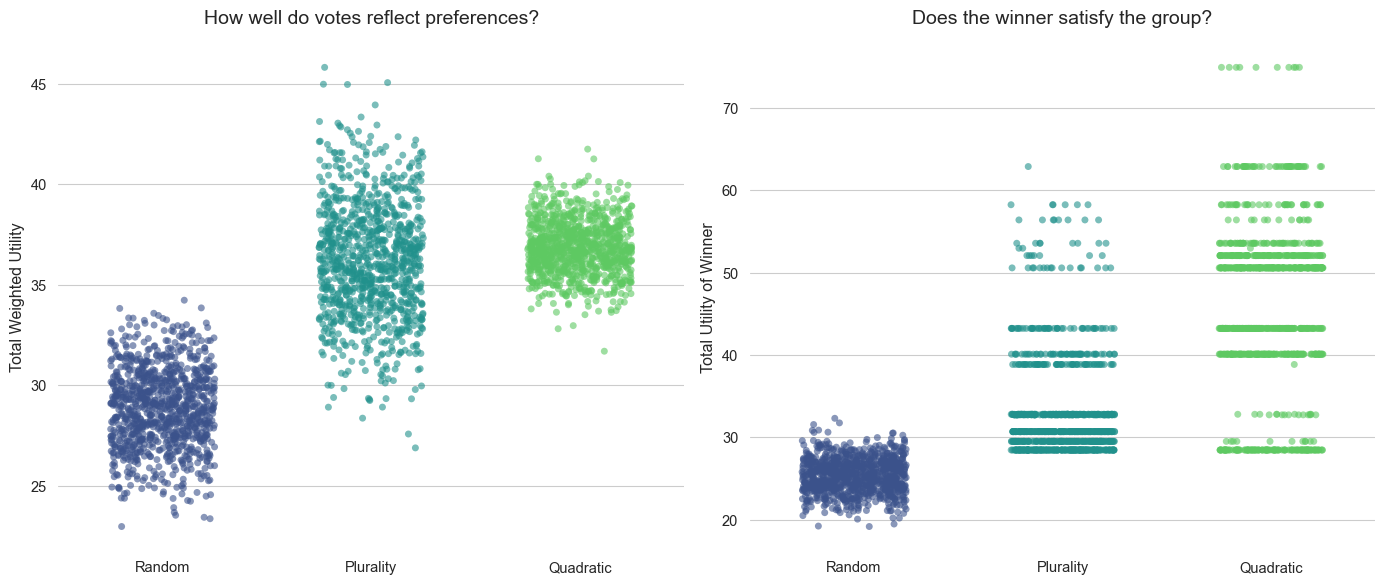

In [61]:
# change voting system labels
metrics_rdm["voting_system"] = "Random"
metrics_plurality["voting_system"] = "Plurality"
metrics_qv["voting_system"] = "Quadratic"

# combine dataframes
combined_df = pd.concat([metrics_rdm, metrics_plurality, metrics_qv], ignore_index=True)

# plot voting metrics
fig = plot_voting_metrics(combined_df)
plt.show()